# Package installization 

In [1]:
%pip install pandas scipy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing the pandas then read the csv file

In [2]:
import pandas as pd
df = pd.read_csv("12_Bank Customer Churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Checking the null values in the dataset

In [3]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

# Display the info of the dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

# Droping the unrelated fetaures

In [5]:
df=df.drop(df[["RowNumber","CustomerId","Surname"]],axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
df.groupby("Geography")["Exited"].apply(lambda x: (x == 1).sum())

Geography
France     811
Germany    814
Spain      413
Name: Exited, dtype: int64

# Creating a new feature(Age Group)

In [7]:
df["AgeGroup"]=pd.cut(df["Age"],bins=[18,30,50,60,100],labels=["Young","Middle","Younger-Old","Elder-Old"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,Middle
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,Middle
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,Middle
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,Middle
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,Middle


In [8]:
df["AgeGroup"].value_counts()

AgeGroup
Middle         6771
Young          1946
Younger-Old     797
Elder-Old       464
Name: count, dtype: int64

In [9]:
df["BalanceCategory"]=pd.cut(df["Balance"],bins=[-1,50000,150000,300000],labels=["Low","Medium","High"])

# Counting the exited customer

In [10]:
df["Exited"].apply(lambda x: "Churned" if x==1 else "Not Churned").value_counts()

Exited
Not Churned    7962
Churned        2038
Name: count, dtype: int64

# Count the customer who raised the complain

In [11]:
df["Complain"].apply(lambda x: "Complained" if x==1 else "Not Complained").value_counts()

Complain
Not Complained    7956
Complained        2044
Name: count, dtype: int64

# Display the customer who raised the complain and exited

In [12]:
nf=df[(df["Exited"]==1) & (df["Complain"]==1)].apply(lambda x: "Churned and Complained" if x["Exited"]==1 and x["Complain"]==1 else "Other", axis=1)
nf.value_counts()

Churned and Complained    2034
Name: count, dtype: int64

# Percentage of churned customers who complained

In [13]:
df.Exited.value_counts()
# ndf=df[(df["Exited"]==1) & (df["Complain"]==1)]
# ndf.count()
churned=df[df["Exited"]==1]

total_churned=churned.shape[0]
complaint_churned=churned[churned["Complain"]==1].shape[0]

percentage=(complaint_churned/total_churned)*100
print(f"Percentage of churned customers who complained: {percentage:.2f}%")
# df[(df["Complain"]==1) & 
#         (df["Exited"]==1)].groupby("AgeGroup").count()# df.count()

# df=df[(df["Exited"]==1) & (df["Complain"]==1)]
# df.count()
# display(df["Satisfaction Score"])
# df = df[(df["Complain"] == 1)]
# df.count()


Percentage of churned customers who complained: 99.80%


In [14]:
geography=df.groupby("Geography")["Exited"].apply(lambda x: (x == 1).sum())
print(geography)

Geography
France     811
Germany    814
Spain      413
Name: Exited, dtype: int64


In [15]:
age_wise=df[
 (df["Exited"]==1)].groupby("AgeGroup").size()
print(age_wise)
# df.count()

AgeGroup
Young           146
Middle         1327
Younger-Old     448
Elder-Old       115
dtype: int64


In [16]:
df.IsActiveMember.value_counts()
# df.Exited.value_counts()
complaint=df[df["Complain"]==0]
complaint.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup,BalanceCategory
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,Middle,Low
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,Middle,Medium
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206,Middle,Low
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251,Middle,Medium
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342,Young,Medium


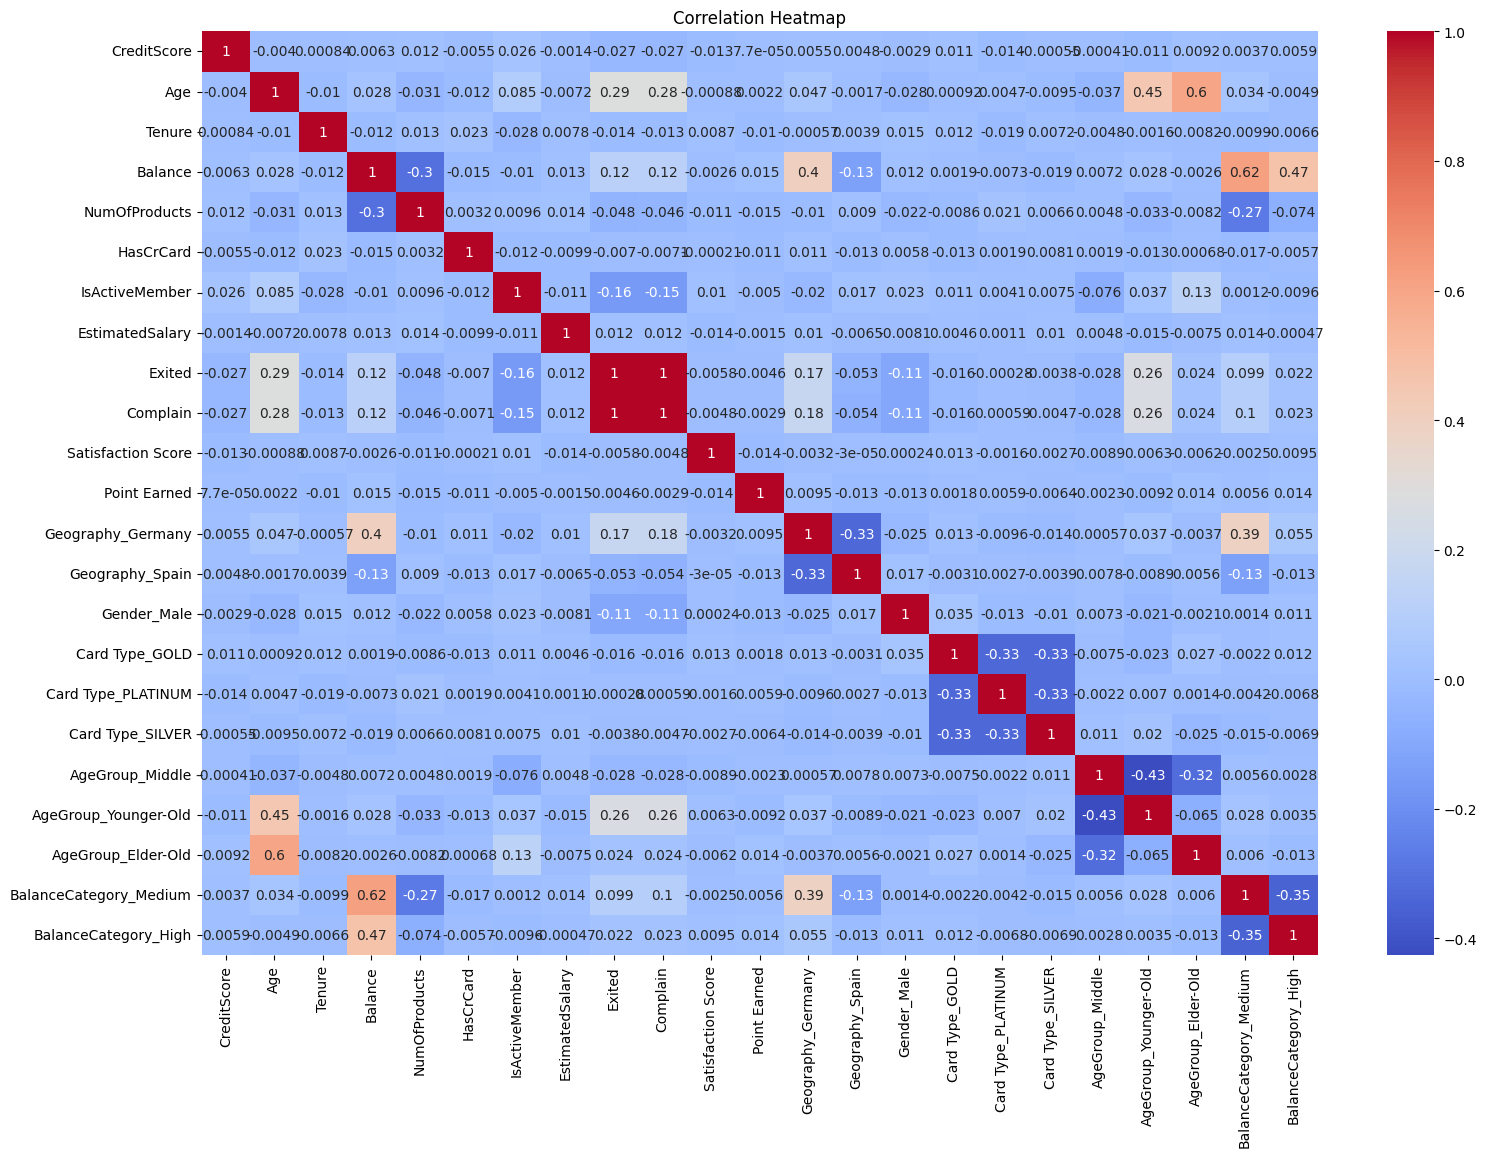

In [17]:
df_encoded=pd.get_dummies(df,drop_first=True)
corr=df_encoded.corr()

import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(18,12))

sns.heatmap(corr,cmap="coolwarm",annot=True)

plt.title("Correlation Heatmap")
plt.show()

# H0: **Complaint and churn are not related**
# H1: **Complaint and churn are related**

In [18]:
from scipy.stats import chi2_contingency

table=pd.crosstab(df["Complain"],df["Exited"])

# print(table)
chi2,p,dof,expected=chi2_contingency(table)
print("P-value:",p) # p value is approx 0.0 whidh is less than 0.05 so we reject the null hypothesis.
#there is strong statistical relationship bwtween complaint and churn.

P-value: 0.0


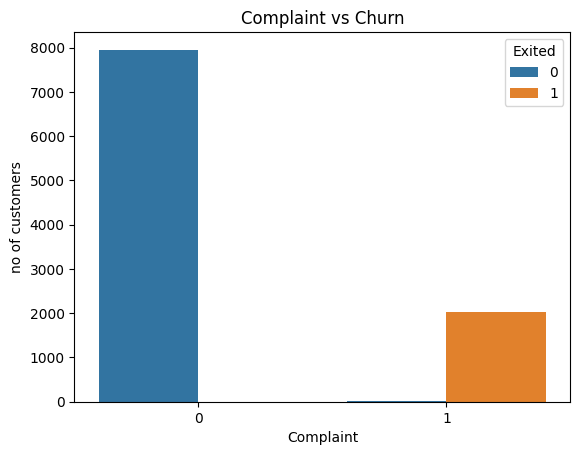

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Complain", hue="Exited", data=df)
plt.title("Complaint vs Churn")
plt.xlabel("Complaint")
plt.ylabel("no of customers")
plt.show()

# H0: Age group and customer churn are independent
# H1: Age group and customer churn are not indenpendent

In [20]:
#old customer churn more

oldcustomer=pd.crosstab(df["AgeGroup"],df["Exited"],normalize="index")
print(oldcustomer)
table=pd.crosstab(df["AgeGroup"],df["Exited"])


chi2,p,dof,expected=chi2_contingency(table)
print("P-value:",p)

Exited              0         1
AgeGroup                       
Young        0.924974  0.075026
Middle       0.804017  0.195983
Younger-Old  0.437892  0.562108
Elder-Old    0.752155  0.247845
P-value: 4.535093227208814e-181


# H0: IsActiveMember and churn are independent
# H1: IsActiveMember and churn are dependent

In [21]:
# active_member_churn=pd.crosstab(df["IsActiveMember"],df["Exited"],normalize="index")
# print(active_member_churn)

table=pd.crosstab(df["IsActiveMember"],df["Exited"])

# print(table)
chi2,p,dof,expected=chi2_contingency(table)
print("P-value:",p)

# product_churn=pd.crosstab(df["NumOfProducts"],df["Exited"],normalize="index")
# print(product_churn)
# satisfaction_churn=pd.crosstab(df["Satisfaction Score"],df["Exited"],normalize="index")
# print(satisfaction_churn)

# bankbalance=pd.crosstab(df["Balance"],df["Exited"],normalize="index")
# print(bankbalance)

P-value: 6.153167438113408e-55


# H0: Number of product and churn are independent
# H1: Number of product and churn are dependent

In [222]:
table=pd.crosstab(df["NumOfProducts"],df["Exited"])

# print(table)
chi2,p,dof,expected=chi2_contingency(table)
print("P-value:",p)

P-value: 0.0
